## Simulações computacionais envolvendo sinais discretos

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

1. Sinais de vibração em máquinas rotativas

Conceito abordado: Amostragem de sinais de alta frequência e análise no domínio do tempo.
Uma máquina a vibrar gera um sinal composto por múltiplas frequências (rotação do motor, harmónicas de falhas em rolamentos). Aqui simulamos esse sinal com ruído adicionado.

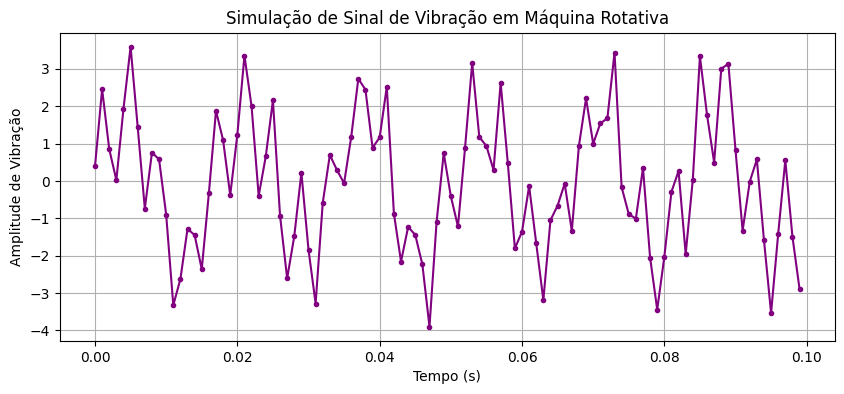

In [ ]:
# Parâmetros de amostragem
Fs = 1000 # Frequência de amostragem (Hz)
t = np.arange(0, 0.1, 1/Fs) # 0.1 segundos de sinal

# Simulação de um sinal de vibração (Soma de senoides + ruído)
# Frequência fundamental do motor (ex: 60Hz) e uma harmónica de defeito (ex: 250Hz)
freq_motor = 60
freq_defeito = 250
ruido = np.random.normal(0, 0.5, len(t))

sinal_vibracao = 2 * np.sin(2 * np.pi * freq_motor * t) + \
                 1.5 * np.sin(2 * np.pi * freq_defeito * t) + ruido

# Visualização
plt.figure(figsize=(10, 4))
plt.plot(t, sinal_vibracao, color='purple', marker='.')
plt.title('Simulação de Sinal de Vibração em Máquina Rotativa')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude de Vibração')
plt.grid(True)
plt.show()

2. Sinais térmicos provenientes de sensores industriais

Conceito abordado: Sistemas com memória (Filtro de Média Móvel) aplicados a sinais de variação lenta corrompidos por ruído.
Sinais térmicos variam lentamente, mas os sensores captam ruído elétrico de alta frequência. Usamos um sistema discreto (média móvel) para suavizar a leitura.

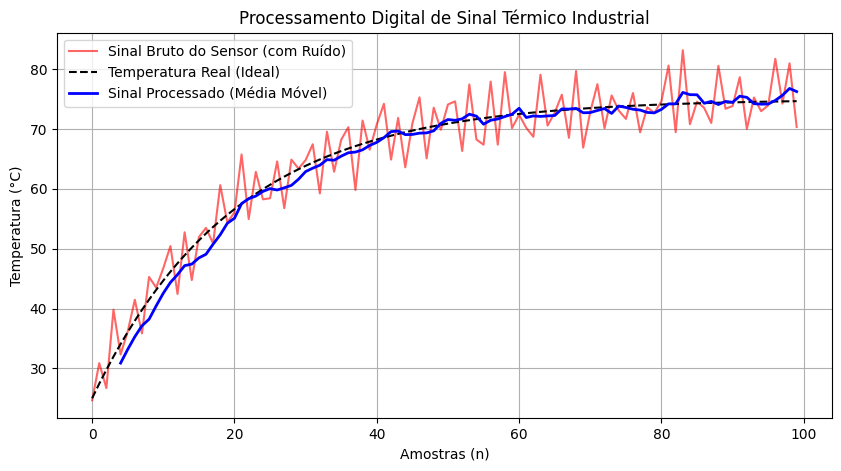

In [ ]:
# Simulação de temperatura ao longo de 100 amostras (crescimento exponencial lento)
n = np.arange(0, 100)
temp_real = 25 + 50 * (1 - np.exp(-n/20)) # Aquece de 25°C até perto de 75°C

# Adicionando ruído elétrico (ex: interferência de 60Hz da rede)
ruido_eletrico = 5 * np.sin(2 * np.pi * 0.4 * n) + np.random.normal(0, 2, len(n))
temp_medida = temp_real + ruido_eletrico

# Sistema de Processamento (Filtro de Média Móvel com Janela = 5)
# y[n] = (x[n] + x[n-1] + x[n-2] + x[n-3] + x[n-4]) / 5
janela = 5
temp_filtrada = np.convolve(temp_medida, np.ones(janela)/janela, mode='valid')

# Compensação de atraso no eixo n para plotagem correta
n_filtrado = np.arange(janela-1, 100)

plt.figure(figsize=(10, 5))
plt.plot(n, temp_medida, label='Sinal Bruto do Sensor (com Ruído)', alpha=0.6, color='red')
plt.plot(n, temp_real, label='Temperatura Real (Ideal)', color='black', linestyle='--')
plt.plot(n_filtrado, temp_filtrada, label='Sinal Processado (Média Móvel)', color='blue', linewidth=2)
plt.title('Processamento Digital de Sinal Térmico Industrial')
plt.xlabel('Amostras (n)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.show()

3. Sinais elétricos em sistemas digitais

Conceito abordado: Cálculo de Energia e Potência Média de um sinal discreto.
Simulamos a transmissão de um pacote de bits num barramento digital e calculamos a energia consumida por esse sinal.

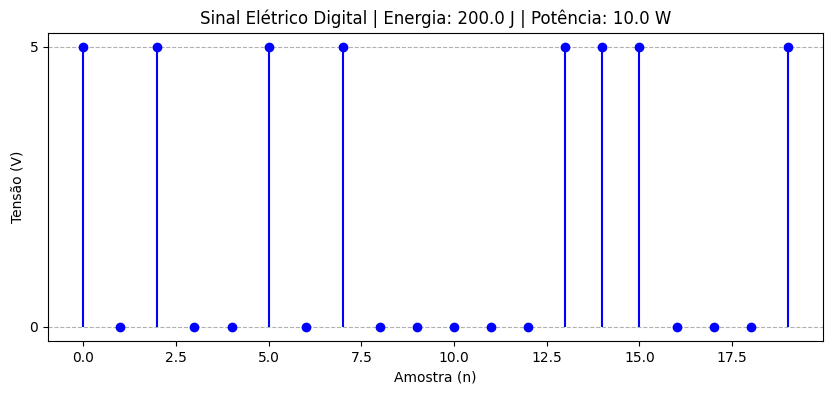

In [ ]:
# Simulação de um pacote de dados digitais (sinal elétrico de tensão em Volts)
# Sequência aleatória de 1s (5V) e 0s (0V)
n_amostras = 20
bits = np.random.randint(0, 2, n_amostras)
tensao = bits * 5.0 # Converte bit 1 para 5V, bit 0 para 0V

# Cálculo de Energia (E = Soma dos quadrados das amplitudes)
energia_discreta = np.sum(tensao**2)

# Cálculo da Potência Média (P = Energia / Número de amostras)
potencia_media = energia_discreta / n_amostras

# Plotando o sinal elétrico (gráfico em degraus/stem para evidenciar o domínio discreto)
plt.figure(figsize=(10, 4))
plt.stem(np.arange(n_amostras), tensao, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.title(f'Sinal Elétrico Digital | Energia: {energia_discreta} J | Potência: {potencia_media} W')
plt.xlabel('Amostra (n)')
plt.ylabel('Tensão (V)')
plt.yticks([0, 5])
plt.grid(True, axis='y', linestyle='--')
plt.show()

4. Sinais de velocidade e rotação de eixos

Conceito abordado: Operação de diferença (derivada discreta) e sistemas lineares simples.
Um encoder mede a posição angular. Para descobrir a velocidade, o processador calcula a diferença entre a posição atual e a anterior.

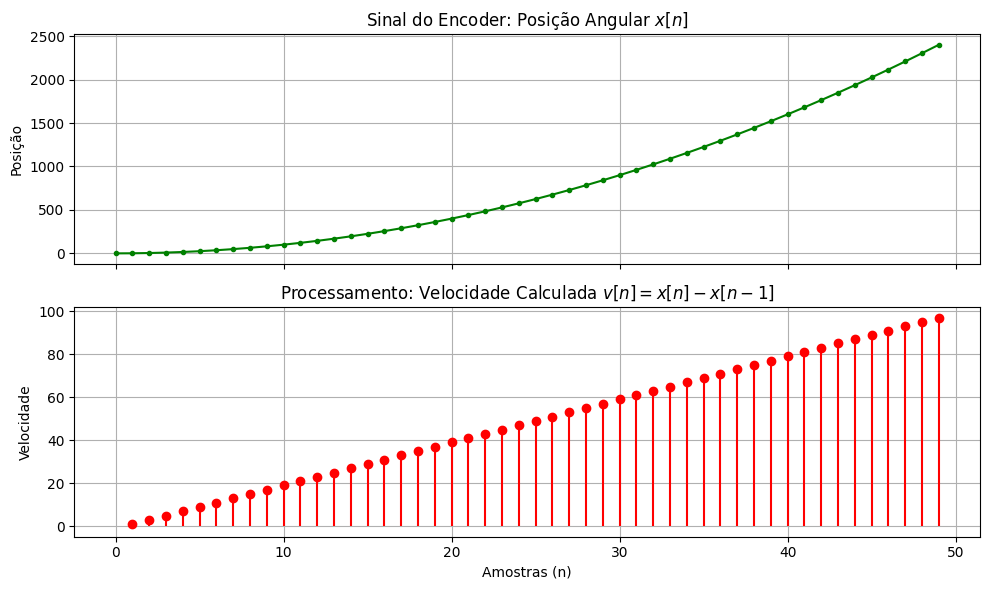

In [ ]:
# Simulação de um eixo em aceleração constante
# Posição quadrática ao longo do tempo (n)
n = np.arange(0, 50)
posicao = 0.5 * 2.0 * (n**2) # Posição angular (x[n])

# Sistema Processador: Derivador Discreto (Diferença para trás)
# v[n] = x[n] - x[n-1]
velocidade = np.diff(posicao) # np.diff faz exatamente a diferença entre elementos adjacentes
n_velocidade = n[1:] # Ajusta o vetor de tempo para a velocidade

# Gráficos
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axs[0].plot(n, posicao, 'g.-')
axs[0].set_title('Sinal do Encoder: Posição Angular $x[n]$')
axs[0].set_ylabel('Posição')
axs[0].grid(True)

axs[1].stem(n_velocidade, velocidade, basefmt=" ", linefmt='r-', markerfmt='ro')
axs[1].set_title('Processamento: Velocidade Calculada $v[n] = x[n] - x[n-1]$')
axs[1].set_xlabel('Amostras (n)')
axs[1].set_ylabel('Velocidade')
axs[1].grid(True)

plt.tight_layout()
plt.show()

5. Sinais adquiridos por sistemas embarcados

Conceito abordado: Análise de Estabilidade (BIBO).
Sistemas embarcados têm memória e limites numéricos restritos. Comparamos um filtro digital estável com um instável para mostrar o que acontece se o projeto matemático estiver incorreto (o sinal vai ao infinito, causando overflow no microcontrolador).

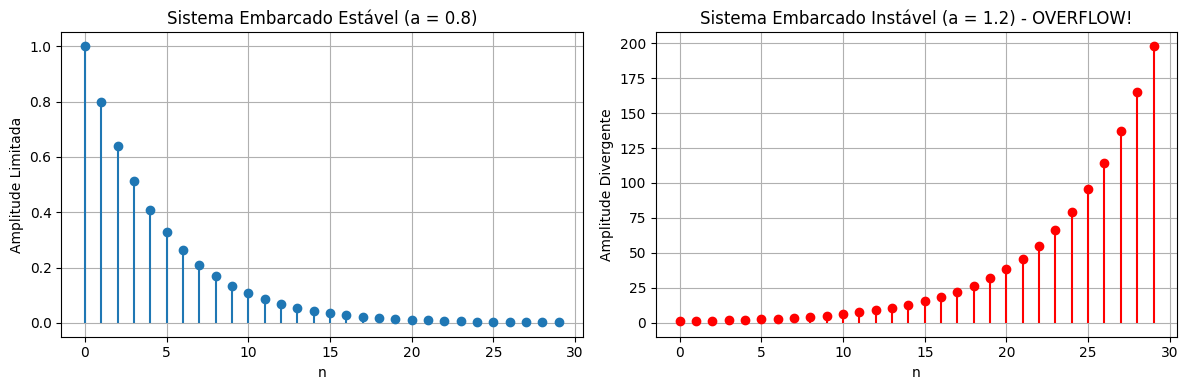

In [ ]:
# Sinal de entrada (Impulso unitário) lido pelo sistema embarcado
n = np.arange(0, 30)
x = np.zeros(30)
x[0] = 1 # Impulso em n=0

# Sistema 1: Filtro Estável (Pólo em 0.8) -> y[n] = 0.8*y[n-1] + x[n]
y_estavel = np.zeros(30)
y_estavel[0] = x[0] # CORREÇÃO: Condição inicial ANTES do loop
for i in range(1, 30):
    y_estavel[i] = 0.8 * y_estavel[i-1] + x[i]

# Sistema 2: Filtro Instável (Pólo em 1.2) -> y[n] = 1.2*y[n-1] + x[n]
y_instavel = np.zeros(30)
y_instavel[0] = x[0] # CORREÇÃO: Condição inicial ANTES do loop
for i in range(1, 30):
    y_instavel[i] = 1.2 * y_instavel[i-1] + x[i]

# Gráficos comparativos
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].stem(n, y_estavel, basefmt=" ")
axs[0].set_title('Sistema Embarcado Estável (a = 0.8)')
axs[0].set_xlabel('n')
axs[0].set_ylabel('Amplitude Limitada')
axs[0].grid(True)

axs[1].stem(n, y_instavel, linefmt='r-', markerfmt='ro', basefmt=" ")
axs[1].set_title('Sistema Embarcado Instável (a = 1.2) - OVERFLOW!')
axs[1].set_xlabel('n')
axs[1].set_ylabel('Amplitude Divergente')
axs[1].grid(True)

plt.tight_layout()
plt.show()